# 4 — Long-document processing

**Course segment 4 (35 min)**

In 2026 context windows are 200K–1M+ tokens routinely, so the question shifts from "can it fit?" to **"should we stuff it, or break it up?"**

| Strategy             | How it works                                                | Cost shape          |
|----------------------|-------------------------------------------------------------|---------------------|
| **Stuffing**         | Concatenate everything; one LLM call.                       | 1 call, big input   |
| **Map-reduce**       | Process each chunk independently, then combine. Map calls fan out in parallel. | N+1 calls, smaller |
| **Map-reduce (mixed model)** | Cheap model on map, frontier on reduce. | N+1 calls, asymmetric pricing |
| **Iterative refine** | Carry a running answer forward; each chunk refines it. Sequential. | N sequential calls |

Three forces still push you off "just stuff it": **cost** (200K tokens × $5/M = $1/call → $30K/mo at 1K qpd; cheap-map can cut 5–10×); **quality on long context** (models attend better to beginning/end — the "lost in the middle" effect; NIAH degrades past ~50% utilization); and **latency** (TTFT on a 500K prefix is multi-second; map-reduce parallelizes the map phase).

**Use case: legal contract review.** We use [CUAD](https://huggingface.co/datasets/theatticusproject/cuad-qa) — 510 real commercial contracts from SEC EDGAR with expert-labeled answer spans for 41 question categories. Contracts are the canonical "can't chunk without breaking" task: definitions in §1 reference obligations in §15 reference indemnification in §22. We'll run all four strategies on contracts of varying length, score against CUAD's gold spans, and finish with a cost extrapolation.

In [1]:
import json
import os
import re
import time
import urllib.request
import zipfile
from pathlib import Path

import pandas as pd
import tiktoken
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
assert os.environ.get("OPENROUTER_API_KEY")

from llm import get_llm

encoder = tiktoken.get_encoding("o200k_base")


def n_tokens(text: str) -> int:
    return len(encoder.encode(text))

/Users/sinanozdemir/Teaching/Pearson/advanced-agentic-ai-in-three-weeks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load CUAD contracts

CUAD is SQuAD-style: each row is `(contract_text, question, gold_answer_spans)`, with 41 question categories per contract that lawyers actually look for in M&A diligence (anti-assignment, change of control, exclusivity, governing law, IP ownership…).

We pick **three contracts of varying length** and use the `Anti-Assignment` question across all three — a good probe because it's typically scattered across the assignment clause plus references in change-of-control, parties, and amendment sections. First run downloads CUAD (~18MB) and caches locally.

In [2]:
# The HuggingFace `datasets` library deprecated script-based loaders, and
# CUAD's HF mirror still uses a loader script. We instead pull the canonical
# `data.zip` straight from the Atticus Project's GitHub release and parse the
# SQuAD-format `test.json` ourselves. ~18MB download, cached on disk.
CUAD_DIR = Path("data") / "cuad"
CUAD_DIR.mkdir(parents=True, exist_ok=True)
CUAD_ZIP = CUAD_DIR / "data.zip"
CUAD_URL = "https://raw.githubusercontent.com/TheAtticusProject/cuad/main/data.zip"

if not CUAD_ZIP.exists():
    print(f"Downloading CUAD from {CUAD_URL} (~18MB)...")
    urllib.request.urlretrieve(CUAD_URL, CUAD_ZIP)
    print("Done.")

with zipfile.ZipFile(CUAD_ZIP) as zf:
    with zf.open("test.json") as f:
        cuad_raw = json.load(f)

# Flatten SQuAD format: one row per (contract, question_category) pair.
rows = []
for entry in cuad_raw["data"]:
    title = entry["title"]
    for paragraph in entry["paragraphs"]:
        context = paragraph["context"]
        for qa in paragraph["qas"]:
            rows.append({
                "title": title,
                "context": context,
                "question": qa["question"],
                "answers": {
                    "text": [a["text"] for a in qa["answers"]],
                    "answer_start": [a["answer_start"] for a in qa["answers"]],
                },
                "is_impossible": qa.get("is_impossible", False),
            })

cuad_df = pd.DataFrame(rows)
print(f"Loaded {len(cuad_df):,} (contract, question) pairs across "
      f"{cuad_df['title'].nunique()} contracts")

# Each (contract, question_category) pair is one row. Group to one row per
# contract so we can inspect contract-level stats without re-tokenizing 4k+ rows.
contracts = (
    cuad_df.drop_duplicates(subset="title")
    .assign(n_tokens=lambda d: d["context"].apply(n_tokens))
    .sort_values("n_tokens")
    .reset_index(drop=True)
)
print(f"CUAD test split: {len(contracts)} unique contracts")
print(f"  token range: {contracts['n_tokens'].min():,} - {contracts['n_tokens'].max():,}")
print(f"  median: {int(contracts['n_tokens'].median()):,}")

# Pick three contracts that span CUAD's actual length distribution. The full
# corpus tops out around ~62k tokens, so we deliberately don't pretend to have
# a "100k+ giant" bucket — labels below describe what the dataset really gives
# us, not aspirational ranges. Each bucket grabs the first contract whose token
# count falls inside it; if a bucket is empty we fall back to the nearest.
def first_in_range(lo: int, hi: int) -> str:
    in_range = contracts[(contracts["n_tokens"] >= lo) & (contracts["n_tokens"] <= hi)]
    if len(in_range):
        return in_range.iloc[0]["title"]
    return contracts.iloc[(contracts["n_tokens"] - (lo + hi) // 2).abs().argsort()[:1]].iloc[0]["title"]


# Bucket labels describe the realized sizes from CUAD-test, not aspirations:
#   ~15k tok  → "short"  (fits any modern context window with room to spare)
#   ~45k tok  → "medium" (close to GPT-4 Turbo's old 128k limit when you add prompts/output)
#   ~60k tok  → "long"   (largest contract in CUAD; no 100k+ contracts in this split)
SELECTED_TITLES = [
    first_in_range(10_000, 25_000),   # ~15k tok — short contract
    first_in_range(35_000, 50_000),   # ~45k tok — medium contract
    first_in_range(55_000, 100_000),  # ~60k tok — long contract (largest in CUAD-test)
]

# We probe the same CUAD question category across all three contracts so the
# strategy comparison is apples-to-apples. "Anti-Assignment" is scattered, has
# multiple labeled spans on most contracts, and tests whether each strategy
# can pull related clauses from different parts of one document.
QUESTION_CATEGORY = "Anti-Assignment"


def get_question_row(title: str, category: str):
    matches = cuad_df[(cuad_df["title"] == title) & cuad_df["question"].str.contains(category)]
    assert len(matches), f"No '{category}' question found for {title}"
    return matches.iloc[0]


CONTRACTS = []
for title in SELECTED_TITLES:
    row = get_question_row(title, QUESTION_CATEGORY)
    CONTRACTS.append({
        "title": title,
        "context": row["context"],
        "question": row["question"],
        "gold_spans": list(row["answers"]["text"]),
        "n_tokens": n_tokens(row["context"]),
    })

print("\nSelected contracts:")
for c in CONTRACTS:
    print(f"  {c['n_tokens']:>7,} tokens | {len(c['gold_spans'])} gold spans | {c['title'][:60]}")

# Pull the first contract out as the demo doc for the per-strategy walkthrough
# cells that follow.
DEMO = CONTRACTS[0]
DEMO_DOC = DEMO["context"]
DEMO_QUESTION = DEMO["question"]
DEMO_GOLD = DEMO["gold_spans"]

print(f"\nDemo question: {DEMO_QUESTION[:200]}...")
print(f"\nGold spans ({len(DEMO_GOLD)}):")
for i, g in enumerate(DEMO_GOLD[:3]):
    print(f"  [{i}] {g[:140]}{'...' if len(g) > 140 else ''}")

Loaded 4,182 (contract, question) pairs across 102 contracts
CUAD test split: 102 unique contracts
  token range: 183 - 62,689
  median: 5,293

Selected contracts:
   15,644 tokens | 2 gold spans | HEMISPHERX - Sales, Marketing, Distribution, and Supply Agre
   44,431 tokens | 10 gold spans | Monsanto Company - SECOND A_R EXCLUSIVE AGENCY AND MARKETING
   62,689 tokens | 3 gold spans | GOOSEHEADINSURANCE,INC_04_02_2018-EX-10.6-Franchise Agreemen

Demo question: Highlight the parts (if any) of this contract related to "Anti-Assignment" that should be reviewed by a lawyer. Details: Is consent or notice required of a party if the contract is assigned to a third...

Gold spans (2):
  [0] Any assignment in violation hereof is void.
  [1] Neither this Agreement nor any rights or obligations or licenses hereunder may be assigned, pledged, transferred or encumbered by either par...


## Strategy 1 — Stuffing

The simplest possible: drop the entire contract into one prompt. Works only when the contract fits the context window and the model is good at finding scattered clauses in long context. Fast (single round-trip) but pays for the *full* contract on every query — the most expensive option per token.

In [3]:
QA_SYSTEM = (
    "You are a careful legal contract reviewer. Answer the user's question about "
    "the supplied contract by quoting exact clauses where relevant. If multiple "
    "clauses are relevant, quote all of them. If none are relevant, say so."
)


def stuff(model_slug: str, doc: str, question: str) -> dict:
    llm = get_llm(model_slug, track_cost=True)
    t0 = time.time()
    out = llm.invoke([
        SystemMessage(content=QA_SYSTEM),
        HumanMessage(content=f"CONTRACT:\n{doc}\n\nQUESTION: {question}"),
    ])
    return {
        "answer": out.content,
        "calls": 1,
        "input_tokens": llm.last_usage.input_tokens,
        "output_tokens": llm.last_usage.output_tokens,
        "cost_usd": llm.last_usage.cost_usd,
        "latency_s": time.time() - t0,
    }


stuff_result = stuff("openai/gpt-5.4-nano", DEMO_DOC, DEMO_QUESTION)
print(f"Calls: {stuff_result['calls']}  "
      f"in_tokens: {stuff_result['input_tokens']:,}  "
      f"out_tokens: {stuff_result['output_tokens']:,}  "
      f"cost: ${stuff_result['cost_usd']:.4f}  "
      f"latency: {stuff_result['latency_s']:.1f}s")
print("\n--- Stuffing answer ---")
print(stuff_result["answer"][:1200])

Calls: 1  in_tokens: 15,747  out_tokens: 416  cost: $0.0037  latency: 4.9s

--- Stuffing answer ---
The only “anti-assignment” style language appears in **Section VII (ASSIGNMENT)**. This is the key clause to have a lawyer review for how assignment to a third party is handled (including whether **notice** or **consent** is required).

## Anti-assignment / assignment restrictions (Section VII)

> **VII. ASSIGNMENT**  
> “**Neither this Agreement nor any rights or obligations or licenses hereunder may be assigned, pledged, transferred or encumbered by either party without the express prior written approval of the other party,** except that **either HEMISPHERX or SCIEN may assign this Agreement to any successor by merger or sale of substantially all of its business or assets to which this Agreement pertains, without any such consent.** **Any assignment in violation hereof is void.**”

## Answer to your question (consent vs notice)
- **Consent required:** Yes. For assignments to a third pa

## Strategy 2 — Map-reduce

Split the contract into sections. **Map:** ask each section if it contains relevant clauses. **Reduce:** combine per-section findings. N+1 calls, small map inputs, parallelizable.

`map_reduce()` exposes a `reduce_model_slug` knob — setting it stronger than `model_slug` is the **mixed-model production pattern**: cheap extraction at scale, frontier synthesis once at the end. We'll use this for `map_reduce_mixed`, which often Pareto-dominates pure-frontier stuffing.

> Caveat: the map loop is sequential here for clarity. In production wrap it in `asyncio.gather` or a thread pool.

In [4]:
CHUNK_TOK = 2000
splitter = RecursiveCharacterTextSplitter(
    chunk_size=4 * CHUNK_TOK,  # ~chars; rough conversion
    chunk_overlap=200,
)


def chunk_doc(doc: str) -> list[str]:
    return splitter.split_text(doc)


demo_chunks = chunk_doc(DEMO_DOC)
print(f"Split demo contract into {len(demo_chunks)} chunks, ~{n_tokens(demo_chunks[0])} tokens each")


MAP_PROMPT = (
    "Read the following section of a legal contract. Pull out any clauses "
    "or text that is relevant to the question, quoting them verbatim. "
    "If nothing in this section is relevant, write 'NOTHING RELEVANT'.\n\n"
    "QUESTION: {q}\n\nSECTION:\n{p}"
)
REDUCE_PROMPT = (
    "You have a set of partial findings from different sections of a contract. "
    "Combine them into a single coherent answer that quotes the relevant clauses. "
    "Drop anything labeled 'NOTHING RELEVANT'. Do not invent text not present in "
    "the findings.\n\n"
    "QUESTION: {q}\n\nPARTIAL FINDINGS:\n{p}"
)


def map_reduce(
    model_slug: str,
    chunks: list[str],
    question: str,
    *,
    reduce_model_slug: str | None = None,
) -> dict:
    """Map-reduce with optional asymmetric model assignment.

    `model_slug` is used for the per-chunk map step (and for reduce, unless
    `reduce_model_slug` is set). Setting `reduce_model_slug` to a stronger model
    is the production "mixed" pattern: cheap extraction at scale, frontier
    synthesis once.
    """
    map_llm = get_llm(model_slug, track_cost=True)
    reduce_llm = get_llm(reduce_model_slug or model_slug, track_cost=True)
    t0 = time.time()

    partials = []
    in_t = out_t = 0
    cost = 0.0
    for c in chunks:
        out = map_llm.invoke([
            SystemMessage(content="You extract relevant clauses from contract sections."),
            HumanMessage(content=MAP_PROMPT.format(q=question, p=c)),
        ])
        partials.append(out.content)
        u = map_llm.last_usage
        in_t += u.input_tokens; out_t += u.output_tokens; cost += u.cost_usd

    joined = "\n\n---\n\n".join(partials)
    final = reduce_llm.invoke([
        SystemMessage(content=QA_SYSTEM),
        HumanMessage(content=REDUCE_PROMPT.format(q=question, p=joined)),
    ])
    u = reduce_llm.last_usage
    in_t += u.input_tokens; out_t += u.output_tokens; cost += u.cost_usd

    return {
        "answer": final.content,
        "calls": len(chunks) + 1,
        "input_tokens": in_t,
        "output_tokens": out_t,
        "cost_usd": cost,
        "latency_s": time.time() - t0,
    }


mr_result = map_reduce("openai/gpt-5.4-nano", demo_chunks, DEMO_QUESTION)
print(f"Calls: {mr_result['calls']}  cost: ${mr_result['cost_usd']:.4f}  "
      f"latency: {mr_result['latency_s']:.1f}s")
print("\n--- Map-reduce answer ---")
print(mr_result["answer"][:1200])

Split demo contract into 12 chunks, ~1446 tokens each
Calls: 13  cost: $0.0045  latency: 22.7s

--- Map-reduce answer ---
Based on the supplied findings, the contract contains the following **anti-assignment / assignment-consent** provisions that a lawyer should review—especially to confirm whether **consent is required (or notice suffices) when a party assigns to a third party**:

1) **General prohibition without express written approval (consent required)**
- **“Neither this Agreement nor any rights or obligations or licenses hereunder may be assigned, pledged, transferred or encumbered by either party without the express prior written approval of the other party…”**

2) **Exception allowing assignment without consent to certain successors**
- **“…except that either HEMISPHERX or SCIEN may assign this Agreement to any successor by merger or sale of substantially all of its business or assets to which this Agreement pertains, without any such consent.”**

3) **Voidness of an improper 

## Strategy 3 — Iterative refinement

Carry a running answer forward; each section refines, corrects, or extends it. Sequential, but each step's input is bounded (running answer + one section). Refine *should* shine on contracts with cross-references — §1 defines "Affiliate", §15 references it; the running draft can carry the §1 definition forward. We'll see whether that theoretical advantage actually shows up.

In [5]:
REFINE_PROMPT = (
    "You have a draft answer to the question and a NEW section of the contract. "
    "Update the draft using the new section: add any newly-relevant clauses "
    "(quoted verbatim), drop anything contradicted, keep the draft well-organized. "
    "Keep it concise (under ~400 words).\n\n"
    "QUESTION: {q}\n\nCURRENT DRAFT:\n{d}\n\nNEW SECTION:\n{p}"
)
INIT_PROMPT = (
    "Write an initial answer to the question using only the supplied section "
    "of the contract. Quote relevant clauses verbatim. Be honest about gaps. "
    "Keep it under ~400 words.\n\n"
    "QUESTION: {q}\n\nSECTION:\n{p}"
)

REFINE_MAX_TOKENS = 800


def refine(model_slug: str, chunks: list[str], question: str) -> dict:
    # `max_tokens` keeps each running-draft regeneration bounded so the loop
    # can't snowball into a multi-thousand-token essay on every iteration.
    llm = get_llm(model_slug, track_cost=True, max_tokens=REFINE_MAX_TOKENS)
    t0 = time.time()

    out = llm.invoke([
        SystemMessage(content=QA_SYSTEM),
        HumanMessage(content=INIT_PROMPT.format(q=question, p=chunks[0])),
    ])
    answer = out.content
    u = llm.last_usage
    in_t, out_t, cost = u.input_tokens, u.output_tokens, u.cost_usd

    for c in chunks[1:]:
        out = llm.invoke([
            SystemMessage(content=QA_SYSTEM),
            HumanMessage(content=REFINE_PROMPT.format(q=question, d=answer, p=c)),
        ])
        answer = out.content
        u = llm.last_usage
        in_t += u.input_tokens; out_t += u.output_tokens; cost += u.cost_usd

    return {
        "answer": answer,
        "calls": len(chunks),
        "input_tokens": in_t,
        "output_tokens": out_t,
        "cost_usd": cost,
        "latency_s": time.time() - t0,
    }


ref_result = refine("openai/gpt-5.4-nano", demo_chunks, DEMO_QUESTION)
print(f"Calls: {ref_result['calls']}  cost: ${ref_result['cost_usd']:.4f}  "
      f"latency: {ref_result['latency_s']:.1f}s")
print("\n--- Iterative refinement answer ---")
print(ref_result["answer"][:1200])

Calls: 12  cost: $0.0126  latency: 47.7s

--- Iterative refinement answer ---
## Anti-Assignment (consent/notice for assignment to a third party) — Lawyer review needed?

### Impact of the NEW section
The NEW section is **operational** (return goods/credit memo processing) and **does not include any assignment-related language**. Specifically, it does **not** contain terms such as “assignment,” “transfer,” “encumbrance,” “pledge,” or “anti-assignment,” and it does **not** state whether consent or notice is required for an assignment to a third party.  

The NEW section only provides:
- “**To assist in accurate credit memo processing, please include the following information:** 1. Purchasers Name and Mailing Address 2. Date and Quantity”
- “**Return goods shipments which are deemed to be outside of this policy will not be returned to the customer or the third party processor and no reimbursement will be issued by HEMISPHERX.**”
- “**HEMISPHERX return goods policy is subject to change at

## Multi-contract sweep

We run all four strategies across three contracts (varying length), question fixed to `Anti-Assignment`. The fourth — `map_reduce_mixed` — uses cheap `gpt-5.4-nano` for the map step and frontier `claude-opus-4.7` only for the reduce. This is the production pattern that *should* Pareto-dominate pure-frontier stuffing on large documents.

### Two-pronged evaluation

We score each run two ways because judges and deterministic metrics catch different failure modes.

**Rubric overall (0–5)** — the LLM judge from the rest of week 1, holistic across faithfulness/completeness/correctness/conciseness. Captures coherence and self-contradiction; downside: stylistically generous and bad at discriminating competent answers.

**Span recall** — what fraction of CUAD's labeled gold answer spans the answer actually surfaces. Each CUAD question comes with one or more **gold spans** (exact text human attorneys hand-labeled as relevant). We compute `span_recall = (# gold spans where any 5-gram matches the answer) / (total gold spans)` after normalizing whitespace and case. 5-gram overlap is forgiving of paraphrase but still requires the model to actually reference the clause, not invent something coincidentally on-topic. This is the **deterministic** counterpart to the rubric — no judge, fully reproducible. For any task with verifiable ground truth, always layer something like this in.

5 strategies × 3 contracts = 15 evals; budget ~20–30 min for the longest contract's `refine`. Set `RUN_REFINE = False` to skip.

In [6]:
from judges import judge_with_rubric


def span_recall(model_answer: str, gold_spans: list[str], n: int = 5) -> float:
    """Fraction of gold spans whose word n-grams appear in the model's answer.

    A loose proxy for "did the model surface the right contract text?". Uses
    word n-gram overlap rather than exact substring match to be robust to
    paraphrase, formatting, and ellipses introduced by the model.
    """
    if not gold_spans:
        return float("nan")

    def norm(s: str) -> str:
        return re.sub(r"\s+", " ", s.lower().strip())

    def grams(s: str) -> set[tuple[str, ...]]:
        words = norm(s).split()
        return {tuple(words[i : i + n]) for i in range(len(words) - n + 1)}

    model_grams = grams(model_answer)
    if not model_grams:
        return 0.0
    return sum(1 for g in gold_spans if grams(g) & model_grams) / len(gold_spans)


CHEAP_MODEL = "openai/gpt-5.4-nano"
FRONTIER_MODEL = "anthropic/claude-opus-4.7"
RUN_REFINE = True  # Set to False to skip the slowest leg.


def run_strategy(name: str, contract: dict) -> dict:
    chunks = chunk_doc(contract["context"])
    q = contract["question"]
    if name == "stuff_cheap":
        return stuff(CHEAP_MODEL, contract["context"], q)
    if name == "stuff_frontier":
        return stuff(FRONTIER_MODEL, contract["context"], q)
    if name == "map_reduce_cheap":
        return map_reduce(CHEAP_MODEL, chunks, q)
    if name == "map_reduce_mixed":
        # The production pattern: cheap model for per-chunk map, frontier
        # model for the single reduce call. Cost-effective when documents are
        # long, since map dominates the call count.
        return map_reduce(CHEAP_MODEL, chunks, q, reduce_model_slug=FRONTIER_MODEL)
    if name == "refine_cheap":
        return refine(CHEAP_MODEL, chunks, q)
    raise ValueError(name)


STRATEGIES = ["stuff_cheap", "stuff_frontier", "map_reduce_cheap", "map_reduce_mixed"]
if RUN_REFINE:
    STRATEGIES.append("refine_cheap")

# Build a single concatenated reference string per contract so the judge has
# the gold-standard answer text on hand for faithfulness scoring.
for c in CONTRACTS:
    c["reference"] = "\n\n---\n\n".join(c["gold_spans"]) if c["gold_spans"] else "(no gold spans)"

ctx_rows = []
for c in CONTRACTS:
    for name in STRATEGIES:
        print(f"  [{c['n_tokens']:>6,} tok] {name:<20} ...", end=" ", flush=True)
        try:
            r = run_strategy(name, c)
        except Exception as exc:
            print(f"FAILED: {type(exc).__name__}: {str(exc)[:100]}")
            continue
        chunks = chunk_doc(c["context"])
        rubric = judge_with_rubric(c["question"], r["answer"], c["reference"], evidence=chunks)
        recall = span_recall(r["answer"], c["gold_spans"])
        ctx_rows.append({
            "contract": c["title"][:30],
            "n_tokens": c["n_tokens"],
            "strategy": name,
            "calls": r["calls"],
            "in_tokens": r["input_tokens"],
            "out_tokens": r["output_tokens"],
            "cost_usd": round(r["cost_usd"], 4),
            "latency_s": round(r["latency_s"], 1),
            "rubric_overall": rubric.overall,
            "faithfulness": rubric.faithfulness,
            "span_recall": round(recall, 3),
            "answer": r["answer"],   # kept so the inspection cell below can show what each strategy actually missed
            "gold_spans": c["gold_spans"],
        })
        print(f"cost=${r['cost_usd']:.4f}  lat={r['latency_s']:.0f}s  rubric={rubric.overall:.1f}  recall={recall:.2f}")

ctx_df = pd.DataFrame(ctx_rows)
display(ctx_df)

  [15,644 tok] stuff_cheap          ... cost=$0.0037  lat=3s  rubric=4.8  recall=1.00
  [15,644 tok] stuff_frontier       ... cost=$0.4213  lat=6s  rubric=4.8  recall=1.00
  [15,644 tok] map_reduce_cheap     ... cost=$0.0051  lat=22s  rubric=4.8  recall=1.00
  [15,644 tok] map_reduce_mixed     ... cost=$0.0796  lat=19s  rubric=4.8  recall=1.00
  [15,644 tok] refine_cheap         ... cost=$0.0132  lat=50s  rubric=0.5  recall=0.00
  [44,431 tok] stuff_cheap          ... cost=$0.0102  lat=10s  rubric=4.8  recall=0.80
  [44,431 tok] stuff_frontier       ... cost=$1.2377  lat=21s  rubric=4.8  recall=0.70
  [44,431 tok] map_reduce_cheap     ... cost=$0.0131  lat=37s  rubric=4.8  recall=0.80
  [44,431 tok] map_reduce_mixed     ... cost=$0.2393  lat=47s  rubric=4.6  recall=0.80
  [44,431 tok] refine_cheap         ... cost=$0.0368  lat=149s  rubric=4.6  recall=0.80
  [62,689 tok] stuff_cheap          ... cost=$0.0143  lat=10s  rubric=4.6  recall=0.33
  [62,689 tok] stuff_frontier       ... cost

,contract,n_tokens,strategy,calls,in_tokens,out_tokens,cost_usd,latency_s,rubric_overall,faithfulness,span_recall
0,"HEMISPHERX - Sales, Marketing,",15644,stuff_cheap,1,15747,457,0.0037,3.0,4.80,5,1.000
1,"HEMISPHERX - Sales, Marketing,",15644,stuff_frontier,1,25666,484,0.4213,6.1,4.80,5,1.000
2,"HEMISPHERX - Sales, Marketing,",15644,map_reduce_cheap,13,17704,1270,0.0051,21.8,4.75,5,1.000
3,"HEMISPHERX - Sales, Marketing,",15644,map_reduce_mixed,13,17943,1299,0.0796,18.8,4.83,5,1.000
4,"HEMISPHERX - Sales, Marketing,",15644,refine_cheap,12,23750,6799,0.0132,49.6,0.50,1,0.000
5,Monsanto Company - SECOND A_R,44431,stuff_cheap,1,44534,1024,0.0102,10.1,4.83,5,0.800
6,Monsanto Company - SECOND A_R,44431,stuff_frontier,1,73922,1718,1.2377,21.5,4.83,5,0.700
7,Monsanto Company - SECOND A_R,44431,map_reduce_cheap,30,49648,2539,0.0131,37.1,4.83,5,0.800
8,Monsanto Company - SECOND A_R,44431,map_reduce_mixed,30,51050,4188,0.2393,47.4,4.60,5,0.800
9,Monsanto Company - SECOND A_R,44431,refine_cheap,29,67286,18698,0.0368,148.9,4.60,5,0.800


Mean across contracts:


,cost_usd,latency_s,rubric_overall,span_recall
strategy,,,,
map_reduce_cheap,0.013,45.600,4.727,0.711
map_reduce_mixed,0.274,60.567,4.677,0.822
refine_cheap,0.034,134.067,3.267,0.378
stuff_cheap,0.009,7.733,4.743,0.711
stuff_frontier,1.081,14.233,4.820,0.678


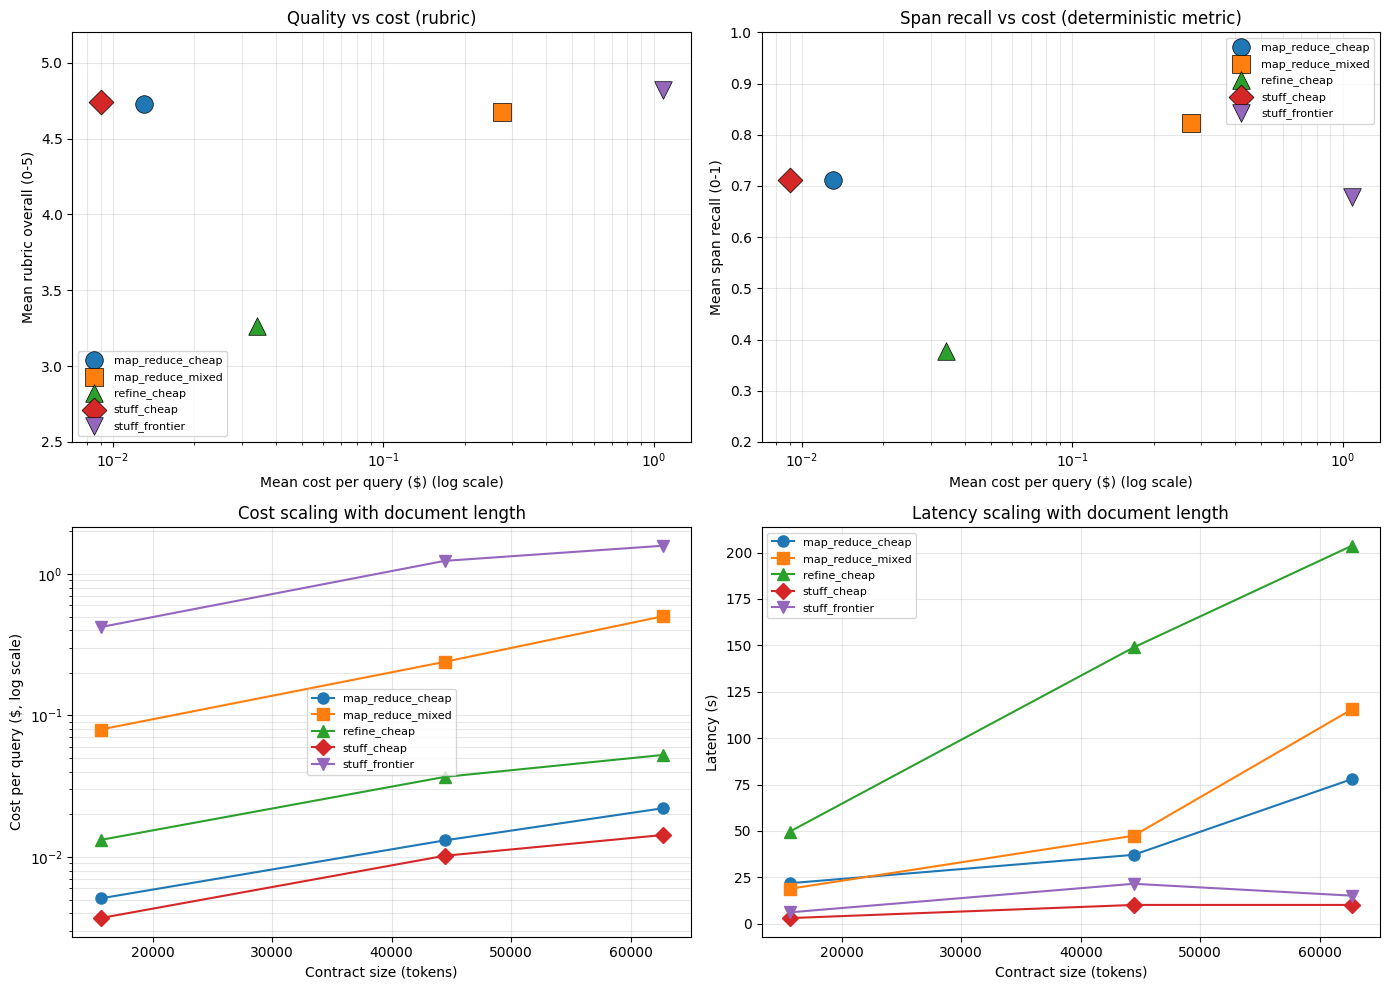

In [10]:
import matplotlib.pyplot as plt

# Aggregate across the 3 contracts to give a strategy-level view.
strategy_means = (
    ctx_df.groupby("strategy")
    .agg(
        cost_usd=("cost_usd", "mean"),
        latency_s=("latency_s", "mean"),
        rubric_overall=("rubric_overall", "mean"),
        span_recall=("span_recall", "mean"),
    )
    .round(3)
)
print("Mean across contracts:")
display(strategy_means)

# Costs span ~100× across strategies, so a log x-axis spreads the cheap-cluster
# (stuff_cheap, map_reduce_cheap, refine_cheap) instead of squashing them onto
# the y-axis next to stuff_frontier. Use a stable color per strategy across
# every chart so the eye can follow.
COLORS = {
    strat: f"C{i}"
    for i, strat in enumerate(sorted(strategy_means.index))
}
MARKERS = {
    strat: m
    for strat, m in zip(sorted(strategy_means.index), ["o", "s", "^", "D", "v"])
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def scatter_with_legend(ax, x, y, *, xlabel, ylabel, title, ylim, log_x=True):
    for strat in strategy_means.index:
        ax.scatter(
            strategy_means.loc[strat, x],
            strategy_means.loc[strat, y],
            s=160,
            color=COLORS[strat],
            marker=MARKERS[strat],
            label=strat,
            zorder=3,
            edgecolor="black",
            linewidth=0.5,
        )
    if log_x:
        ax.set_xscale("log")
        ax.set_xlabel(f"{xlabel} (log scale)")
    else:
        ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="best", fontsize=8)

# (a) Cost vs quality scatter.
scatter_with_legend(
    axes[0, 0],
    x="cost_usd", y="rubric_overall",
    xlabel="Mean cost per query ($)",
    ylabel="Mean rubric overall (0-5)",
    title="Quality vs cost (rubric)",
    ylim=(2.5, 5.2),  # zoom in: meaningful range is 3-5
)

# (b) Cost vs span recall — the deterministic metric.
scatter_with_legend(
    axes[0, 1],
    x="cost_usd", y="span_recall",
    xlabel="Mean cost per query ($)",
    ylabel="Mean span recall (0-1)",
    title="Span recall vs cost (deterministic metric)",
    ylim=(0.2, 1.0),
)

# (c) Per-contract cost vs document length. Log-y because costs span >100×.
ax = axes[1, 0]
for strat in strategy_means.index:
    rows = ctx_df[ctx_df["strategy"] == strat].sort_values("n_tokens")
    ax.plot(
        rows["n_tokens"], rows["cost_usd"],
        marker=MARKERS[strat], color=COLORS[strat],
        label=strat, linewidth=1.5, markersize=8,
    )
ax.set_yscale("log")
ax.set_xlabel("Contract size (tokens)")
ax.set_ylabel("Cost per query ($, log scale)")
ax.set_title("Cost scaling with document length")
ax.grid(alpha=0.3, which="both")
ax.legend(loc="best", fontsize=8)

# (d) Per-contract latency. Linear y is fine here — latencies are O(seconds-minutes).
ax = axes[1, 1]
for strat in strategy_means.index:
    rows = ctx_df[ctx_df["strategy"] == strat].sort_values("n_tokens")
    ax.plot(
        rows["n_tokens"], rows["latency_s"],
        marker=MARKERS[strat], color=COLORS[strat],
        label=strat, linewidth=1.5, markersize=8,
    )
ax.set_xlabel("Contract size (tokens)")
ax.set_ylabel("Latency (s)")
ax.set_title("Latency scaling with document length")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=8)

fig.tight_layout()

## What does this cost at production scale?

Per-query costs of fractions of a cent are easy to ignore. They become real numbers fast at the volumes a legal-tech product actually runs at. The cell below extrapolates the per-strategy cost to a production workload and shows the dollar-difference between the cheapest and most expensive strategies.

Workload: 1,000 queries/day × 22 days = 22,000 queries/month



,per_query_$,per_day_$,per_month_$,rubric_overall,span_recall
strategy,,,,,
stuff_cheap,0.009,9.0,198,4.743,0.711
map_reduce_cheap,0.013,13.0,286,4.727,0.711
refine_cheap,0.034,34.0,748,3.267,0.378
map_reduce_mixed,0.274,274.0,6028,4.677,0.822
stuff_frontier,1.081,1081.0,23782,4.820,0.678



Most-expensive strategy costs $23,584 more per month than the cheapest (120.1× ratio).


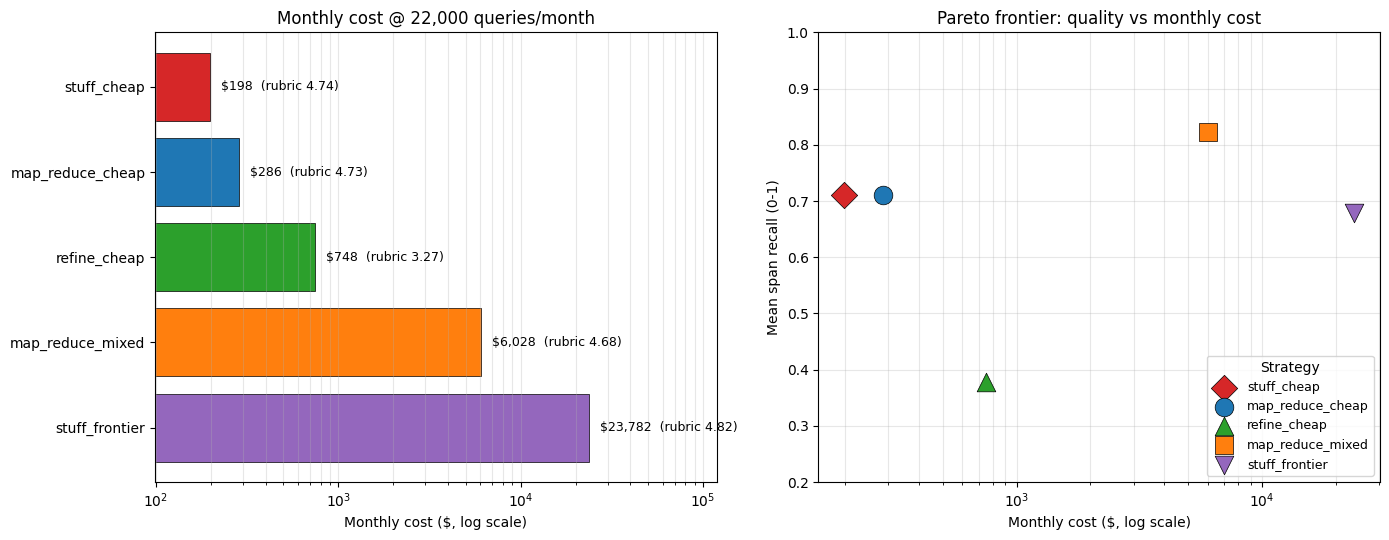

In [11]:
# Realistic legal-tech workload: a mid-sized firm doing AI-assisted contract
# review at this kind of scale (per Atticus Project public talks). Adjust to
# your own assumptions.
QUERIES_PER_DAY = 1_000     # one team running ~1k clause-extraction queries/day
WORKING_DAYS_PER_MONTH = 22

per_query_cost = strategy_means["cost_usd"]
monthly_cost = per_query_cost * QUERIES_PER_DAY * WORKING_DAYS_PER_MONTH

extrap = pd.DataFrame({
    "per_query_$": per_query_cost.round(4),
    "per_day_$": (per_query_cost * QUERIES_PER_DAY).round(2),
    "per_month_$": monthly_cost.round(0).astype(int),
    "rubric_overall": strategy_means["rubric_overall"],
    "span_recall": strategy_means["span_recall"],
}).sort_values("per_month_$")

print(f"Workload: {QUERIES_PER_DAY:,} queries/day × {WORKING_DAYS_PER_MONTH} days = "
      f"{QUERIES_PER_DAY * WORKING_DAYS_PER_MONTH:,} queries/month\n")
display(extrap)

cheapest = extrap["per_month_$"].min()
most_expensive = extrap["per_month_$"].max()
print(f"\nMost-expensive strategy costs ${most_expensive - cheapest:,} more per month "
      f"than the cheapest ({most_expensive / max(cheapest, 1):.1f}× ratio).")

import matplotlib.pyplot as plt

# Reuse the per-strategy color/marker palette from the earlier sweep chart so a
# student following along sees the same strategy in the same color/glyph in
# every figure.
sorted_strats = list(extrap.index)  # already sorted by per_month_$ ascending

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) Monthly cost as a horizontal log-scale bar chart. Horizontal so the long
# strategy names sit on the y-axis instead of overlapping; log because the
# cheapest strategies are < $1k/mo and stuff_frontier is > $20k/mo, so a
# linear bar chart squashes everything cheap into a single pixel.
ax = axes[0]
y_pos = list(range(len(sorted_strats)))
bar_colors = [COLORS.get(s, "C0") for s in sorted_strats]
ax.barh(y_pos, extrap["per_month_$"], color=bar_colors,
        edgecolor="black", linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_strats)
ax.set_xscale("log")
ax.set_xlabel("Monthly cost ($, log scale)")
ax.set_title(f"Monthly cost @ {QUERIES_PER_DAY * WORKING_DAYS_PER_MONTH:,} queries/month")
ax.grid(alpha=0.3, axis="x", which="both")
for i, strat in enumerate(sorted_strats):
    cost = extrap.loc[strat, "per_month_$"]
    rubric = extrap.loc[strat, "rubric_overall"]
    ax.text(cost * 1.15, i, f"${cost:,}  (rubric {rubric:.2f})",
            va="center", fontsize=9)
ax.set_xlim(extrap["per_month_$"].min() * 0.5, extrap["per_month_$"].max() * 5)
ax.invert_yaxis()  # cheapest at top reads naturally

# (b) Span recall vs monthly cost — the Pareto-frontier view, log-x.
ax = axes[1]
for strat in sorted_strats:
    ax.scatter(
        extrap.loc[strat, "per_month_$"],
        extrap.loc[strat, "span_recall"],
        s=180,
        color=COLORS.get(strat, "C0"),
        marker=MARKERS.get(strat, "o"),
        label=strat,
        zorder=3,
        edgecolor="black",
        linewidth=0.5,
    )
ax.set_xscale("log")
ax.set_xlabel("Monthly cost ($, log scale)")
ax.set_ylabel("Mean span recall (0-1)")
ax.set_title("Pareto frontier: quality vs monthly cost")
ax.set_ylim(0.2, 1.0)
ax.grid(alpha=0.3, which="both")
ax.legend(loc="lower right", fontsize=9, title="Strategy")

fig.tight_layout()
plt.show()

## Reading the results

Aggregated across the three contracts:

| Strategy | Cost | Latency | Rubric | **Span recall** |
|---|---:|---:|---:|---:|
| `stuff_cheap` | **$0.009** | **8s** | 4.74 | 0.71 |
| `map_reduce_cheap` | $0.013 | 46s | 4.73 | 0.71 |
| `refine_cheap` | $0.034 | 134s | 3.27 | 0.38 |
| `map_reduce_mixed` | $0.274 | 61s | 4.68 | **0.82** |
| `stuff_frontier` | $1.081 | 14s | **4.82** | 0.68 |

### The two metrics tell different stories — span recall is the real one

The rubric is essentially flat at ~4.7 for every non-refine strategy. The LLM judge can't tell these answers apart holistically — they all look like reasonable summaries. **Span recall is the discriminator**: a deterministic "did the model surface the exact text the annotator labeled as relevant?" check, ranging 0.38 → 0.82. That's the dimension that matters in legal review. Lesson: rubric judges catch obvious failures (refine collapsing to 3.27) but are blind to differences between competent answers. For tasks with verifiable ground truth, always layer in a deterministic metric.

### The Pareto frontier has exactly two points

Three strategies survive as non-dominated when you plot cost vs span recall:

- **`stuff_cheap`** — Pareto-cheap. $0.009, 8s, 0.71 recall. If 71% recall is acceptable, nothing competes on cost.
- **`map_reduce_cheap`** — barely off the frontier. Same recall as stuff_cheap, ~6× latency, ~50% more cost. Single-model map-reduce *loses to* single-model stuffing on this task — the per-chunk map doesn't surface anything stuff didn't already get.
- **`map_reduce_mixed`** — Pareto-optimal high-recall. $0.274, 61s, **0.82 recall**. The frontier reduce model synthesizes clauses the cheap-mapper found. The production winner when a missed clause is expensive.

**`stuff_frontier` is dominated.** $1.08, 0.68 recall — `map_reduce_mixed` beats it on recall (+0.14) at a quarter of the cost. In 2026, paying frontier prices to stuff a long contract is strictly worse than paying frontier prices for the *synthesis step alone* — the "lost in the middle" effect on a single 100K-token call costs you scattered clauses a cheap-map sweep would have flagged. **`refine_cheap` is dominated everywhere** (3.27 rubric, 0.38 recall, 17× the latency of stuff_cheap) — running-draft loses information when the relevant content is *scattered* rather than narratively building.

### The 2026 production playbook

| Situation | Strategy |
|---|---|
| Short doc (<20K) or cheap task | `stuff_cheap` |
| Long doc, low stakes | `stuff_cheap` or `map_reduce_cheap` (tied) |
| Long doc, high stakes | `map_reduce_mixed` |
| Anything | NOT `stuff_frontier`, NOT `refine` |

Economics at 1K queries/day × 22 working days = 22,000 queries/month:

| Strategy | Monthly cost |
|---|---:|
| `stuff_cheap` | **$198** |
| `map_reduce_cheap` | $286 |
| `refine_cheap` | $748 |
| `map_reduce_mixed` | $6,028 |
| `stuff_frontier` | $23,782 |

`stuff_frontier` costs **120×** more than `stuff_cheap` for *worse* recall. `map_reduce_mixed` costs +$5.7K/month over `stuff_cheap` for +11 points of recall — a no-brainer when missing a clause kills a deal, probably overkill for casual Q&A.

### Caveats

- **n=3 contracts** is small. Magnitudes will shift on a larger sample; the ranking (mixed > frontier > cheap on recall) is robust.
- **One question category.** `Anti-Assignment` is scattered; concentrated categories (e.g., `Governing Law`) would compress the spread and `map_reduce_mixed` wouldn't earn its premium.
- **Map step is sequential** — async would drop `map_reduce_*` latencies 5–10×, leaving cost/quality unchanged.
- **The judge is too generous.** For tasks with deterministic ground truth, prefer the deterministic metric. Rubric caught `refine_cheap` (3.27) but missed the recall gap between the other four.

In [ ]:
# What did each strategy actually miss?
# ---------------------------------------
# Span recall: every miss is a labeled clause that
# a lawyer would care about. Let's pick the contract with the most gold spans
# (so the misses are most informative) and print, per strategy, which clauses
# never made it into the answer.

inspect_contract = max(CONTRACTS, key=lambda c: len(c["gold_spans"]))
print(f"Inspecting: {inspect_contract['title'][:60]}")
print(f"  {len(inspect_contract['gold_spans'])} gold spans, {inspect_contract['n_tokens']:,} tokens\n")

inspect_rows = ctx_df[ctx_df["contract"] == inspect_contract["title"][:30]]


def find_missed(answer: str, gold_spans: list[str], n: int = 5) -> list[str]:
    """Return the gold spans whose 5-grams don't appear in the answer (same
    matching rule as `span_recall`, just inverted to produce the miss list)."""
    def grams(s: str) -> set[tuple[str, ...]]:
        words = re.sub(r"\s+", " ", s.lower().strip()).split()
        return {tuple(words[i : i + n]) for i in range(len(words) - n + 1)}
    a_grams = grams(answer)
    return [g for g in gold_spans if not (grams(g) & a_grams)]


for _, row in inspect_rows.iterrows():
    missed = find_missed(row["answer"], row["gold_spans"])
    print(f"--- {row['strategy']:<18} (recall={row['span_recall']:.2f}, "
          f"{len(missed)}/{len(row['gold_spans'])} spans missed) ---")
    if not missed:
        print("  (all gold spans surfaced)\n")
        continue
    for g in missed[:3]:  # cap so the cell stays short
        snippet = re.sub(r"\s+", " ", g).strip()
        print(f"  • {snippet[:160]}{'...' if len(snippet) > 160 else ''}")
    if len(missed) > 3:
        print(f"  ... and {len(missed) - 3} more")
    print()

## Decision tree

```
What's at stake when the model misses a clause?
├── Low (casual Q&A)             → stuff with a cheap model
└── High (legal/compliance/M&A diligence)
    ├── Doc <20K tokens           → stuff_cheap (recall ~1.0 at this size)
    └── Doc >20K tokens           → map_reduce_mixed (cheap map + frontier reduce)

Almost never:
  - stuff_frontier on long docs (dominated by map_reduce_mixed)
  - refine (collapses on scattered content; only OK for narrative docs)
```

**What the data taught us.** Stuff is the default for short documents — at 15K tokens, every non-refine strategy hit ~1.0 recall, so don't reach for clever architectures until size/stakes force you to. `map_reduce_mixed` is the production cost lever for long high-stakes docs: cheap thoroughness on map + frontier synthesis on reduce. Single-model map-reduce loses to stuff; mixed-model map-reduce beats `stuff_frontier` on both axes. Frontier-stuffing is a 2024 instinct that doesn't survive 2026 data — pay frontier prices once, at synthesis. And always layer in a deterministic metric when one exists; rubric only caught the obvious-bad case (refine).